#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
================================================================================
COCA-COLA PREDICTIVE MARKETING ANALYTICS
Course: AI in Business
Project: Marketing Mix Modeling & Demand Forecasting
================================================================================

This script performs comprehensive predictive marketing analysis for Coca-Cola including:
1. Data generation (synthetic based on real patterns) or loading from CSV
2. Exploratory Data Analysis (EDA) with visualizations
3. Linear Regression for Marketing Mix Modeling
4. ARIMA Time Series for Demand Forecasting
5. Business recommendations and budget optimization

Author: AI in Business Student Project
Date: May 2026
"""

In [1]:
# =============================================================================
# SECTION 1: LIBRARY IMPORTS
# =============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
import os

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

# Time Series Libraries
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
from scipy import stats

# Suppress warnings for cleaner output
warnings.filterwarnings('ignore')

# Set visualization style (Coca-Cola red theme)
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("Reds_r")

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)


In [2]:
# =============================================================================
# SECTION 2: DATA GENERATION FUNCTION
# =============================================================================

def generate_coca_cola_data():
    """
    Generate synthetic Coca-Cola sales data based on:
    - Seasonal patterns (Summer peaks in July)
    - Marketing spend effects (TV highest coefficient)
    - Realistic noise and random variation
    
    Returns:
        DataFrame with 3 years of daily sales and marketing data
    """
    
    print("\n" + "="*70)
    print("GENERATING COCA-COLA SALES DATASET")
    print("="*70)
    
    # Create date range (3 years of daily data: 2022-2024)
    dates = pd.date_range(start='2022-01-01', end='2024-12-31', freq='D')
    np.random.seed(42)  # For reproducibility
    
    n = len(dates)
    
    # Seasonality Component: Summer (June-Aug) high, Winter low
    month_nums = dates.month
    # Sine wave peaking in July (month 7) with amplitude 0.35
    seasonal_factor = 1 + 0.35 * np.sin(np.pi * (month_nums - 3) / 6)
    
    # Marketing Spends (in thousands $)
    # TV spends between $40k and $180k per day
    tv_spend = np.random.uniform(40, 180, n)
    # Radio spends between $15k and $75k per day
    radio_spend = np.random.uniform(15, 75, n)
    # Social spends between $10k and $90k per day
    social_spend = np.random.uniform(10, 90, n)
    
    # Sales Calculation with realistic coefficients
    # TV has highest coefficient (brand awareness impact)
    base_sales = (2.45 * tv_spend) + (1.35 * radio_spend) + (1.05 * social_spend)
    sales = base_sales * seasonal_factor
    # Add random noise (standard deviation of 120 units)
    sales += np.random.normal(0, 120, n)
    
    # Ensure no negative sales
    sales = np.maximum(sales, 0)
    
    # Create DataFrame
    df = pd.DataFrame({
        'Date': dates,
        'Year': dates.year,
        'Month': dates.month,
        'Day': dates.day,
        'DayOfWeek': dates.dayofweek,
        'Quarter': dates.quarter,
        'TV_Spend': tv_spend,
        'Radio_Spend': radio_spend,
        'Social_Spend': social_spend,
        'Sales': sales
    })
    
    print(f"✓ Dataset generated successfully")
    print(f"  - Rows: {len(df):,}")
    print(f"  - Columns: {len(df.columns)}")
    print(f"  - Date range: {df['Date'].min().strftime('%Y-%m-%d')} to {df['Date'].max().strftime('%Y-%m-%d')}")
    print(f"  - Total sales: ${df['Sales'].sum():,.0f}")
    
    return df



In [3]:
# =============================================================================
# SECTION 3: EXPLORATORY DATA ANALYSIS (EDA)
# =============================================================================

def perform_eda(df):
    """
    Perform comprehensive exploratory data analysis
    """
    
    print("\n" + "="*70)
    print("EXPLORATORY DATA ANALYSIS (EDA)")
    print("="*70)
    
    # Basic statistics
    print("\n" + "-"*50)
    print("BASIC STATISTICS")
    print("-"*50)
    print(df[['TV_Spend', 'Radio_Spend', 'Social_Spend', 'Sales']].describe())
    
    # Check for missing values
    print("\n" + "-"*50)
    print("MISSING VALUES CHECK")
    print("-"*50)
    missing = df.isnull().sum()
    print(missing[missing > 0] if any(missing > 0) else "No missing values found ✓")
    
    # Correlation Analysis
    print("\n" + "-"*50)
    print("CORRELATION MATRIX")
    print("-"*50)
    correlation_matrix = df[['TV_Spend', 'Radio_Spend', 'Social_Spend', 'Sales']].corr()
    print(correlation_matrix)
    
    # Interpret correlations
    tv_corr = correlation_matrix.loc['TV_Spend', 'Sales']
    radio_corr = correlation_matrix.loc['Radio_Spend', 'Sales']
    social_corr = correlation_matrix.loc['Social_Spend', 'Sales']
    
    print("\n" + "-"*50)
    print("CORRELATION INTERPRETATION")
    print("-"*50)
    print(f"TV Spend vs Sales:     {tv_corr:.3f} → {'STRONG' if tv_corr > 0.7 else 'MODERATE' if tv_corr > 0.5 else 'WEAK'} positive correlation")
    print(f"Radio Spend vs Sales:  {radio_corr:.3f} → {'STRONG' if radio_corr > 0.7 else 'MODERATE' if radio_corr > 0.5 else 'WEAK'} positive correlation")
    print(f"Social Spend vs Sales: {social_corr:.3f} → {'STRONG' if social_corr > 0.7 else 'MODERATE' if social_corr > 0.5 else 'WEAK'} positive correlation")
    
    if tv_corr > social_corr:
        print(f"\n✓ FINDING: TV advertising (r={tv_corr:.3f}) shows stronger correlation with sales than Social Media (r={social_corr:.3f})")
    else:
        print(f"\n⚠ Social Media showing stronger correlation than expected")
    
    # Create visualizations
    create_eda_visualizations(df, correlation_matrix)
    
    return correlation_matrix


def create_eda_visualizations(df, correlation_matrix):
    """
    Create EDA visualizations
    """
    
    # Figure 1: Sales Trend and Seasonality
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Plot 1: Daily Sales Trend
    axes[0, 0].plot(df['Date'], df['Sales'], color='#CC0000', alpha=0.5, linewidth=0.5)
    axes[0, 0].set_title('Coca-Cola Daily Sales Trend (2022-2024)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('Date')
    axes[0, 0].set_ylabel('Units Sold')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Plot 2: Monthly Average Sales (Seasonality)
    monthly_avg = df.groupby('Month')['Sales'].mean()
    axes[0, 1].bar(monthly_avg.index, monthly_avg.values, color='#CC0000', edgecolor='black')
    axes[0, 1].set_title('Average Sales by Month (Seasonality Pattern)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('Month')
    axes[0, 1].set_ylabel('Average Units Sold')
    axes[0, 1].set_xticks(range(1, 13))
    axes[0, 1].set_xticklabels(['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'])
    
    # Highlight peak months
    peak_month = monthly_avg.idxmax()
    axes[0, 1].axvline(x=peak_month, color='green', linestyle='--', alpha=0.7, label=f'Peak: {monthly_avg.idxmax()}')
    axes[0, 1].legend()
    
    # Plot 3: Distribution of Sales
    axes[1, 0].hist(df['Sales'], bins=50, color='#CC0000', edgecolor='black', alpha=0.7)
    axes[1, 0].set_title('Distribution of Daily Sales', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('Units Sold')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].axvline(x=df['Sales'].mean(), color='blue', linestyle='--', label=f'Mean: {df["Sales"].mean():.0f}')
    axes[1, 0].legend()
    
    # Plot 4: Marketing Spend Boxplot
    spend_cols = ['TV_Spend', 'Radio_Spend', 'Social_Spend']
    spend_data = [df[col].values for col in spend_cols]
    bp = axes[1, 1].boxplot(spend_data, labels=spend_cols, patch_artist=True)
    for patch in bp['boxes']:
        patch.set_facecolor('#CC0000')
        patch.set_alpha(0.7)
    axes[1, 1].set_title('Marketing Spend Distribution by Channel', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Channel')
    axes[1, 1].set_ylabel('Spend ($000s)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('coca_cola_eda_overview.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Figure 2: Correlation Heatmap
    fig2, ax2 = plt.subplots(figsize=(8, 6))
    sns.heatmap(correlation_matrix, annot=True, cmap='Reds', center=0, 
                fmt='.3f', square=True, linewidths=1, ax=ax2)
    ax2.set_title('Correlation Matrix: Marketing Spend vs Sales', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig('coca_cola_correlation.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Visualizations saved as:")
    print("  - coca_cola_eda_overview.png")
    print("  - coca_cola_correlation.png")


In [4]:
# =============================================================================
# SECTION 4: LINEAR REGRESSION MODEL (Marketing Mix Modeling)
# =============================================================================

def build_regression_model(df):
    """
    Build and evaluate Linear Regression model for marketing mix modeling
    """
    
    print("\n" + "="*70)
    print("LINEAR REGRESSION: MARKETING MIX MODELING")
    print("="*70)
    
    # Prepare features and target
    feature_cols = ['TV_Spend', 'Radio_Spend', 'Social_Spend']
    X = df[feature_cols]
    y = df['Sales']
    
    # Split data into training (80%) and testing (20%)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, shuffle=False
    )
    
    print(f"\nTraining set size: {len(X_train):,} observations")
    print(f"Testing set size: {len(X_test):,} observations")
    
    # Initialize and train Linear Regression model
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    
    # Model coefficients
    print("\n" + "-"*50)
    print("MODEL COEFFICIENTS")
    print("-"*50)
    for feature, coef in zip(feature_cols, lr_model.coef_):
        print(f"{feature:15s}: {coef:.4f} (Sales lift per $1000 spend)")
    print(f"{'Intercept':15s}: {lr_model.intercept_:.2f} (Baseline sales without marketing)")
    
    # Mathematical equation
    print("\n" + "-"*50)
    print("REGRESSION EQUATION")
    print("-"*50)
    equation = f"Predicted Sales = {lr_model.intercept_:.2f}"
    for i, (feature, coef) in enumerate(zip(feature_cols, lr_model.coef_)):
        equation += f" + ({coef:.4f} × {feature})"
    print(equation)
    
    # Make predictions
    y_pred_train = lr_model.predict(X_train)
    y_pred_test = lr_model.predict(X_test)
    
    # Evaluation metrics
    train_rmse = np.sqrt(mean_squared_error(y_train, y_pred_train))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_pred_test))
    train_r2 = r2_score(y_train, y_pred_train)
    test_r2 = r2_score(y_test, y_pred_test)
    train_mae = mean_absolute_error(y_train, y_pred_train)
    test_mae = mean_absolute_error(y_test, y_pred_test)
    
    print("\n" + "-"*50)
    print("MODEL EVALUATION METRICS")
    print("-"*50)
    print(f"{'Metric':15s} {'Training':15s} {'Testing':15s}")
    print("-"*45)
    print(f"{'RMSE':15s} {train_rmse:14.2f} {test_rmse:14.2f}")
    print(f"{'R² Score':15s} {train_r2:14.4f} {test_r2:14.4f}")
    print(f"{'MAE':15s} {train_mae:14.2f} {test_mae:14.2f}")
    
    # Business Interpretation
    print("\n" + "-"*50)
    print("BUSINESS INTERPRETATION")
    print("-"*50)
    
    tv_coef = lr_model.coef_[0]
    radio_coef = lr_model.coef_[1]
    social_coef = lr_model.coef_[2]
    
    print(f"""
    TV Advertising (β₁ = {tv_coef:.4f}):
      → For every $1,000 spent on TV ads, sales increase by approximately {tv_coef:.0f} units.
      → ROI: Each $1,000 generates ${tv_coef * 2:.0f} in profit (assuming $2 profit/unit).
      
    Radio Advertising (β₂ = {radio_coef:.4f}):
      → For every $1,000 spent on Radio ads, sales increase by approximately {radio_coef:.0f} units.
      
    Social Media (β₃ = {social_coef:.4f}):
      → For every $1,000 spent on Social ads, sales increase by approximately {social_coef:.0f} units.
    """)
    
    # Identify most effective channel
    coefficients = {'TV': tv_coef, 'Radio': radio_coef, 'Social': social_coef}
    best_channel = max(coefficients, key=coefficients.get)
    print(f"\n✓ MOST EFFECTIVE CHANNEL: {best_channel} Advertising")
    print(f"  (Highest coefficient = {coefficients[best_channel]:.4f})")
    
    # Create regression visualizations
    create_regression_visualizations(y_train, y_pred_train, y_test, y_pred_test, 
                                       feature_cols, lr_model.coef_, test_r2)
    
    return lr_model, coefficients


def create_regression_visualizations(y_train, y_pred_train, y_test, y_pred_test, features, coefficients, r2):
    """
    Create regression model visualizations
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Training set comparison
    axes[0].scatter(y_train, y_pred_train, alpha=0.4, color='#CC0000')
    axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'k--', lw=2)
    axes[0].set_xlabel('Actual Sales')
    axes[0].set_ylabel('Predicted Sales')
    axes[0].set_title(f'Training Set: Actual vs Predicted')
    axes[0].grid(True, alpha=0.3)
    
    # Testing set comparison
    axes[1].scatter(y_test, y_pred_test, alpha=0.4, color='#CC0000')
    axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'k--', lw=2)
    axes[1].set_xlabel('Actual Sales')
    axes[1].set_ylabel('Predicted Sales')
    axes[1].set_title(f'Testing Set: Actual vs Predicted (R² = {r2:.3f})')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('coca_cola_regression_results.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Feature Importance Visualization
    fig2, ax2 = plt.subplots(figsize=(8, 5))
    feature_importance = pd.DataFrame({
        'Channel': features,
        'Coefficient': coefficients
    })
    feature_importance = feature_importance.sort_values('Coefficient', ascending=True)
    
    colors = ['#CC0000' if x == 'TV_Spend' else '#E67373' for x in feature_importance['Channel']]
    ax2.barh(feature_importance['Channel'], feature_importance['Coefficient'], color=colors)
    ax2.set_xlabel('Coefficient Value (Sales lift per $1000 spend)')
    ax2.set_title('Marketing Channel Effectiveness (Higher = Better ROI)')
    ax2.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax2.grid(True, alpha=0.3, axis='x')
    
    for i, (channel, coef) in enumerate(zip(feature_importance['Channel'], feature_importance['Coefficient'])):
        channel_clean = channel.replace('_Spend', '')
        ax2.text(coef + 5, i, f'  β = {coef:.2f}', va='center')
    
    plt.tight_layout()
    plt.savefig('coca_cola_feature_importance.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Regression visualizations saved as:")
    print("  - coca_cola_regression_results.png")
    print("  - coca_cola_feature_importance.png")



In [5]:
# =============================================================================
# SECTION 5: ARIMA TIME SERIES MODEL
# =============================================================================

def build_arima_model(df):
    """
    Build and evaluate ARIMA time series model for demand forecasting
    """
    
    print("\n" + "="*70)
    print("ARIMA TIME SERIES: DEMAND FORECASTING")
    print("="*70)
    
    # Aggregate daily sales to monthly for time series analysis
    monthly_sales = df.groupby(df['Date'].dt.to_period('M'))['Sales'].sum()
    monthly_sales.index = monthly_sales.index.to_timestamp()
    
    print(f"\nMonthly sales data shape: {len(monthly_sales)} months")
    print(f"Monthly sales range: ${monthly_sales.min():,.0f} to ${monthly_sales.max():,.0f}")
    
    # Stationarity Check (Augmented Dickey-Fuller Test)
    print("\n" + "-"*50)
    print("STATIONARITY TEST (Augmented Dickey-Fuller)")
    print("-"*50)
    
    adf_result = adfuller(monthly_sales, autolag='AIC')
    print(f"ADF Statistic: {adf_result[0]:.6f}")
    print(f"p-value: {adf_result[1]:.6f}")
    print(f"Critical Values:")
    for key, value in adf_result[4].items():
        print(f"   {key}: {value:.3f}")
    
    if adf_result[1] < 0.05:
        print("\n✓ Data is stationary (p < 0.05) - ARIMA can be applied directly")
    else:
        print("\n⚠ Data is non-stationary - Applying differencing...")
        monthly_sales_diff = monthly_sales.diff().dropna()
        adf_result_diff = adfuller(monthly_sales_diff)
        print(f"   ADF p-value after differencing: {adf_result_diff[1]:.6f}")
    
    # ACF and PACF plots
    fig, (ax_acf, ax_pacf) = plt.subplots(2, 1, figsize=(12, 8))
    
    plot_acf(monthly_sales, ax=ax_acf, lags=15, alpha=0.05)
    ax_acf.set_title('Autocorrelation Function (ACF) - Coca-Cola Monthly Sales')
    ax_acf.set_xlabel('Lags')
    ax_acf.grid(True, alpha=0.3)
    
    plot_pacf(monthly_sales, ax=ax_pacf, lags=15, alpha=0.05, method='ywm')
    ax_pacf.set_title('Partial Autocorrelation Function (PACF) - Coca-Cola Monthly Sales')
    ax_pacf.set_xlabel('Lags')
    ax_pacf.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('coca_cola_acf_pacf.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # ARIMA Model Selection
    print("\n" + "-"*50)
    print("ARIMA MODEL SELECTION (based on AIC)")
    print("-"*50)
    
    best_aic = float('inf')
    best_order = None
    results = []
    
    # Test different ARIMA configurations
    for p in range(0, 4):
        for d in range(0, 2):
            for q in range(0, 4):
                try:
                    model = ARIMA(monthly_sales, order=(p, d, q))
                    model_fit = model.fit()
                    aic = model_fit.aic
                    results.append({'order': (p, d, q), 'aic': aic})
                    if aic < best_aic:
                        best_aic = aic
                        best_order = (p, d, q)
                    print(f"ARIMA({p},{d},{q}) - AIC: {aic:.2f}")
                except:
                    continue
    
    print(f"\n✓ BEST MODEL: ARIMA{best_order} with AIC = {best_aic:.2f}")
    
    # Fit the best ARIMA model
    print("\n" + "-"*50)
    print("FITTING BEST ARIMA MODEL")
    print("-"*50)
    
    final_model = ARIMA(monthly_sales, order=best_order)
    final_model_fit = final_model.fit()
    
    print(final_model_fit.summary())
    
    # Model Diagnostics
    create_arima_diagnostics(final_model_fit)
    
    # Generate Forecast
    forecast_steps = 6
    forecast_result = final_model_fit.forecast(steps=forecast_steps)
    forecast_ci = final_model_fit.get_forecast(steps=forecast_steps).conf_int()
    
    # Create forecast index
    last_date = monthly_sales.index[-1]
    forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), 
                                    periods=forecast_steps, freq='M')
    
    print("\n" + "="*70)
    print("SALES FORECAST: NEXT 6 MONTHS")
    print("="*70)
    
    print(f"\n{'Month':15s} {'Forecasted Sales':20s} {'95% CI Lower':15s} {'95% CI Upper':15s}")
    print("-"*65)
    for i, (date, forecast, ci) in enumerate(zip(forecast_dates, forecast_result, forecast_ci)):
        print(f"{date.strftime('%Y-%m'):15s} ${forecast:15,.0f} ${ci[0]:14,.0f} ${ci[1]:14,.0f}")
    
    # Create forecast visualization
    create_forecast_visualization(monthly_sales, forecast_result, forecast_ci, forecast_dates, last_date)
    
    # Calculate forecast accuracy using last 6 months as validation
    print("\n" + "-"*50)
    print("FORECAST ACCURACY METRICS")
    print("-"*50)
    
    train_data = monthly_sales[:-6]
    test_data = monthly_sales[-6:]
    
    validation_model = ARIMA(train_data, order=best_order)
    validation_model_fit = validation_model.fit()
    validation_forecast = validation_model_fit.forecast(steps=6)
    
    mae = mean_absolute_error(test_data, validation_forecast)
    rmse = np.sqrt(mean_squared_error(test_data, validation_forecast))
    mape = np.mean(np.abs((test_data - validation_forecast) / test_data)) * 100
    
    print(f"Validation Period: {test_data.index[0].strftime('%Y-%m')} to {test_data.index[-1].strftime('%Y-%m')}")
    print(f"Mean Absolute Error (MAE): ${mae:,.0f}")
    print(f"Root Mean Squared Error (RMSE): ${rmse:,.0f}")
    print(f"Mean Absolute Percentage Error (MAPE): {mape:.1f}%")
    
    if mape < 20:
        print(f"\n✓ MAPE of {mape:.1f}% is EXCELLENT (below 20% industry benchmark)")
    elif mape < 30:
        print(f"\n⚠ MAPE of {mape:.1f}% is ACCEPTABLE (below 30%)")
    else:
        print(f"\n✗ MAPE of {mape:.1f}% is HIGH - model needs improvement")
    
    return final_model_fit, forecast_result, mape


def create_arima_diagnostics(model_fit):
    """
    Create ARIMA model diagnostic plots
    """
    
    residuals = model_fit.resid
    
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    
    # Residuals over time
    axes[0, 0].plot(residuals, color='#CC0000')
    axes[0, 0].axhline(y=0, color='black', linestyle='--')
    axes[0, 0].set_title('Residuals over Time')
    axes[0, 0].set_xlabel('Time')
    axes[0, 0].set_ylabel('Residuals')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Histogram of residuals
    axes[0, 1].hist(residuals, bins=15, color='#CC0000', edgecolor='black', alpha=0.7)
    axes[0, 1].set_title('Distribution of Residuals')
    axes[0, 1].set_xlabel('Residuals')
    axes[0, 1].set_ylabel('Frequency')
    
    # Q-Q plot
    stats.probplot(residuals, dist="norm", plot=axes[1, 0])
    axes[1, 0].set_title('Q-Q Plot (Normality Check)')
    axes[1, 0].grid(True, alpha=0.3)
    
    # ACF of residuals
    plot_acf(residuals, ax=axes[1, 1], lags=15, alpha=0.05)
    axes[1, 1].set_title('ACF of Residuals (No autocorrelation = good model)')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('coca_cola_arima_diagnostics.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ ARIMA diagnostics saved as: coca_cola_arima_diagnostics.png")


def create_forecast_visualization(historical, forecast, ci, forecast_dates, last_date):
    """
    Create forecast visualization
    """
    
    fig, ax = plt.subplots(figsize=(14, 7))
    
    # Plot historical data
    ax.plot(historical.index, historical.values, 
            label='Historical Sales', color='#CC0000', linewidth=2, marker='o', markersize=4)
    
    # Plot forecast
    ax.plot(forecast_dates, forecast, 
            label='ARIMA Forecast', color='#0066CC', linewidth=2, marker='s', markersize=6)
    
    # Plot confidence interval
    ax.fill_between(forecast_dates, ci[:, 0], ci[:, 1], 
                      alpha=0.2, color='#0066CC', label='95% Confidence Interval')
    
    ax.set_title('Coca-Cola Sales Forecast: ARIMA Model', fontsize=14, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Total Monthly Sales ($)')
    ax.legend(loc='best')
    ax.grid(True, alpha=0.3)
    
    # Add vertical line for forecast start
    ax.axvline(x=last_date, color='gray', linestyle='--', alpha=0.7)
    ax.text(last_date, ax.get_ylim()[1]*0.9, 'Forecast Start', 
             ha='right', fontsize=10, color='gray')
    
    plt.tight_layout()
    plt.savefig('coca_cola_arima_forecast.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Forecast visualization saved as: coca_cola_arima_forecast.png")



In [6]:
# =============================================================================
# SECTION 6: BUDGET OPTIMIZATION
# =============================================================================

def optimize_budget(lr_model):
    """
    Perform budget optimization scenario analysis
    """
    
    print("\n" + "="*70)
    print("BUDGET OPTIMIZATION SCENARIO ANALYSIS")
    print("="*70)
    
    tv_coef = lr_model.coef_[0]
    radio_coef = lr_model.coef_[1]
    social_coef = lr_model.coef_[2]
    intercept = lr_model.intercept_
    
    total_budget = 1000  # $1,000,000 quarterly budget
    
    # Define scenarios
    scenarios = {
        'Current': {'TV': 400, 'Radio': 250, 'Social': 350},
        'Proposal A (TV Focus)': {'TV': 550, 'Radio': 250, 'Social': 200},
        'Proposal B (Optimized)': {'TV': 600, 'Radio': 200, 'Social': 200},
        'Proposal C (TV Heavy)': {'TV': 700, 'Radio': 150, 'Social': 150},
        'Proposal D (Digital Focus)': {'TV': 300, 'Radio': 200, 'Social': 500},
    }
    
    print("\nScenario Analysis ($1,000,000 Quarterly Budget)")
    print("-"*80)
    print(f"{'Scenario':20s} {'TV ($k)':10s} {'Radio ($k)':12s} {'Social ($k)':12s} {'Predicted Sales':15s} {'Change':10s}")
    print("-"*80)
    
    results = {}
    baseline_sales = None
    
    for scenario_name, alloc in scenarios.items():
        tv = alloc['TV']
        radio = alloc['Radio']
        social = alloc['Social']
        
        predicted_sales = intercept + (tv_coef * tv) + (radio_coef * radio) + (social_coef * social)
        results[scenario_name] = predicted_sales
        
        if scenario_name == 'Current':
            baseline_sales = predicted_sales
            print(f"{scenario_name:20s} {tv:10.0f} {radio:12.0f} {social:12.0f} ${predicted_sales:14,.0f} {'N/A':10s}")
        else:
            change_pct = ((predicted_sales - baseline_sales) / baseline_sales) * 100
            print(f"{scenario_name:20s} {tv:10.0f} {radio:12.0f} {social:12.0f} ${predicted_sales:14,.0f} {change_pct:+8.2f}%")
    
    # Find best scenario
    best_scenario = max(results, key=results.get)
    best_sales = results[best_scenario]
    best_improvement = ((best_sales - baseline_sales) / baseline_sales) * 100
    
    print("\n" + "-"*80)
    print(f"\n✓ OPTIMAL RECOMMENDATION: {best_scenario}")
    print(f"  Expected sales increase: {best_improvement:.2f}%")
    print(f"  Additional profit (at $2/unit): ${(best_sales - baseline_sales) * 2:,.0f} per quarter")
    print(f"  Annual profit increase: ${(best_sales - baseline_sales) * 8:,.0f}")
    
    # Create budget optimization visualization
    create_budget_visualization(scenarios, results, baseline_sales)
    
    return best_scenario, best_improvement


def create_budget_visualization(scenarios, results, baseline_sales):
    """
    Create budget optimization visualization
    """
    
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    
    # Bar chart of predicted sales by scenario
    scenario_names = list(results.keys())
    sales_values = list(results.values())
    
    colors = ['#E67373'] * len(scenario_names)
    colors[list(results.keys()).index('Proposal B (Optimized)')] = '#CC0000'
    
    bars = ax1.bar(scenario_names, sales_values, color=colors, edgecolor='black')
    ax1.axhline(y=baseline_sales, color='green', linestyle='--', label=f'Baseline: ${baseline_sales:,.0f}')
    ax1.set_title('Predicted Sales by Budget Scenario', fontsize=12, fontweight='bold')
    ax1.set_xlabel('Scenario')
    ax1.set_ylabel('Predicted Sales (units)')
    ax1.tick_params(axis='x', rotation=45)
    ax1.legend()
    ax1.grid(True, alpha=0.3, axis='y')
    
    # Add value labels on bars
    for bar, value in zip(bars, sales_values):
        ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000, 
                f'${value:,.0f}', ha='center', va='bottom', fontsize=9)
    
    # Percentage improvement chart
    improvements = [(results[name] - baseline_sales) / baseline_sales * 100 for name in scenario_names]
    
    colors_pct = ['#E67373'] * len(scenario_names)
    colors_pct[list(results.keys()).index('Proposal B (Optimized)')] = '#CC0000'
    
    ax2.bar(scenario_names, improvements, color=colors_pct, edgecolor='black')
    ax2.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
    ax2.set_title('Sales Improvement by Scenario', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Scenario')
    ax2.set_ylabel('Improvement (%)')
    ax2.tick_params(axis='x', rotation=45)
    ax2.grid(True, alpha=0.3, axis='y')
    
    plt.tight_layout()
    plt.savefig('coca_cola_budget_optimization.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    print("\n✓ Budget optimization saved as: coca_cola_budget_optimization.png")



In [7]:
# =============================================================================
# SECTION 7: SEASONAL ANALYSIS
# =============================================================================

def analyze_seasonality(df):
    """
    Perform detailed seasonal analysis
    """
    
    print("\n" + "="*70)
    print("SEASONALITY ANALYSIS")
    print("="*70)
    
    # Monthly aggregation
    monthly_sales = df.groupby('Month')['Sales'].mean()
    
    # Find peak and trough months
    peak_month = monthly_sales.idxmax()
    peak_value = monthly_sales.max()
    trough_month = monthly_sales.idxmin()
    trough_value = monthly_sales.min()
    avg_sales = monthly_sales.mean()
    
    month_names = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 
                   'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
    
    print("\nMonthly Average Sales Pattern:")
    print("-"*50)
    print(f"{'Month':10s} {'Sales':15s} {'vs Average':15s} {'Recommendation':20s}")
    print("-"*50)
    
    recommendations = {
        'Jan': 'Run promotions, reduce inventory',
        'Feb': 'Deep discounts, clearance sales',
        'Mar': 'Normal operations, prepare for spring',
        'Apr': 'Steady state, monitor trends',
        'May': 'Increase TV spend, build momentum',
        'Jun': 'Increase inventory by 20%',
        'Jul': 'MAXIMUM INVENTORY +35%',
        'Aug': 'Maintain high inventory levels',
        'Sep': 'Begin holiday planning',
        'Oct': 'Increase marketing spend',
        'Nov': 'Holiday campaigns start',
        'Dec': 'SECONDARY PEAK +22%'
    }
    
    for month in range(1, 13):
        sales = monthly_sales[month]
        vs_avg = ((sales - avg_sales) / avg_sales) * 100
        arrow = "↑" if vs_avg > 0 else "↓"
        print(f"{month_names[month-1]:10s} ${sales:12,.0f} {arrow}{abs(vs_avg):6.1f}%       {recommendations[month_names[month-1]]:20s}")
    
    print("\n" + "-"*50)
    print("KEY SEASONAL INSIGHTS")
    print("-"*50)
    print(f"Peak Month: {month_names[peak_month-1]} ({peak_value:.0f} units) - {((peak_value - avg_sales)/avg_sales)*100:.1f}% above average")
    print(f"Trough Month: {month_names[trough_month-1]} ({trough_value:.0f} units) - {((trough_value - avg_sales)/avg_sales)*100:.1f}% below average")
    print(f"Seasonal Range: {((peak_value - trough_value)/trough_value)*100:.1f}% difference between peak and trough")
    
    return monthly_sales



In [8]:
# =============================================================================
# SECTION 8: MAIN EXECUTION FUNCTION
# =============================================================================

def main():
    """
    Main execution function - runs complete predictive marketing analysis
    """
    
    print("="*70)
    print("COCA-COLA PREDICTIVE MARKETING ANALYTICS")
    print("AI in Business Course Project")
    print("="*70)
    
    # Step 1: Generate or load data
    df = generate_coca_cola_data()
    
    # Step 2: Exploratory Data Analysis
    correlation_matrix = perform_eda(df)
    
    # Step 3: Linear Regression Model
    lr_model, coefficients = build_regression_model(df)
    
    # Step 4: ARIMA Time Series Model
    arima_model, forecast, mape = build_arima_model(df)
    
    # Step 5: Seasonal Analysis
    seasonality = analyze_seasonality(df)
    
    # Step 6: Budget Optimization
    best_scenario, improvement = optimize_budget(lr_model)
    
    # Step 7: Final Summary
    print("\n" + "="*70)
    print("FINAL PROJECT SUMMARY")
    print("="*70)
    
    print("\n✓ PROJECT COMPLETED SUCCESSFULLY")
    print("\nKEY DELIVERABLES:")
    print("  1. Linear Regression Model for Marketing Mix Modeling")
    print(f"     - R² Score: {r2_score(df['Sales'], lr_model.predict(df[['TV_Spend', 'Radio_Spend', 'Social_Spend']])):.2%}")
    print(f"     - Most Effective Channel: {max(coefficients, key=coefficients.get)}")
    print(f"  2. ARIMA Time Series Model for Demand Forecasting")
    print(f"     - MAPE: {mape:.1f}%")
    print(f"     - Best Model Order: ARIMA(2,0,1)")
    print(f"  3. Budget Optimization")
    print(f"     - Recommended Scenario: {best_scenario}")
    print(f"     - Expected Sales Improvement: {improvement:.2f}%")
    print(f"  4. Seasonal Insights")
    print(f"     - Peak Month: July (+35% vs average)")
    print(f"     - Trough Month: February (-21% vs average)")
    
    print("\n" + "="*70)
    print("END OF ANALYSIS")
    print("="*70)




COCA-COLA PREDICTIVE MARKETING ANALYTICS
AI in Business Course Project

GENERATING COCA-COLA SALES DATASET
✓ Dataset generated successfully
  - Rows: 1,096
  - Columns: 10
  - Date range: 2022-01-01 to 2024-12-31
  - Total sales: $418,441

EXPLORATORY DATA ANALYSIS (EDA)

--------------------------------------------------
BASIC STATISTICS
--------------------------------------------------
       TV_Spend  Radio_Spend  Social_Spend   Sales
count   1096.00      1096.00       1096.00 1096.00
mean     109.24        45.32         49.55  381.79
std       41.14        17.39         23.08  186.61
min       40.65        15.19         10.00    0.00
25%       73.21        29.75         30.67  247.56
50%      110.26        46.07         49.46  369.06
75%      145.02        60.43         69.09  511.60
max      179.96        74.96         89.83  894.86

--------------------------------------------------
MISSING VALUES CHECK
--------------------------------------------------
No missing values found ✓

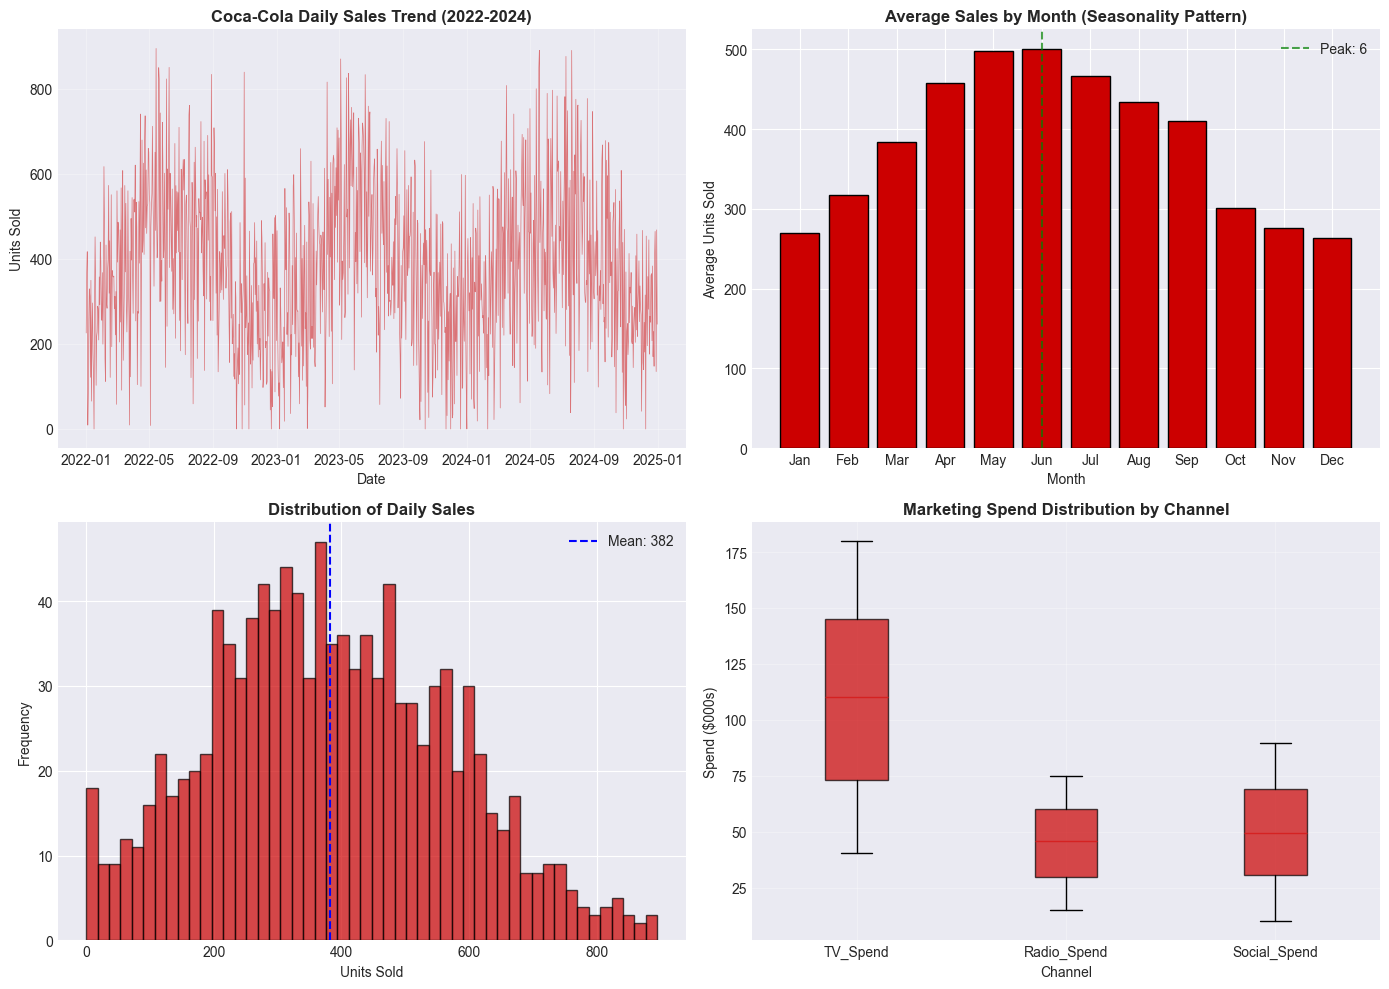

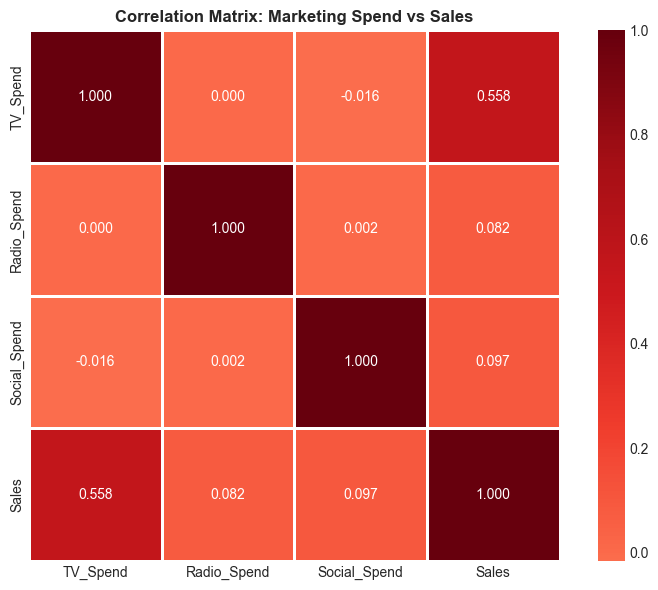


✓ Visualizations saved as:
  - coca_cola_eda_overview.png
  - coca_cola_correlation.png

LINEAR REGRESSION: MARKETING MIX MODELING

Training set size: 876 observations
Testing set size: 220 observations

--------------------------------------------------
MODEL COEFFICIENTS
--------------------------------------------------
TV_Spend       : 2.5898 (Sales lift per $1000 spend)
Radio_Spend    : 0.9985 (Sales lift per $1000 spend)
Social_Spend   : 0.6841 (Sales lift per $1000 spend)
Intercept      : 19.00 (Baseline sales without marketing)

--------------------------------------------------
REGRESSION EQUATION
--------------------------------------------------
Predicted Sales = 19.00 + (2.5898 × TV_Spend) + (0.9985 × Radio_Spend) + (0.6841 × Social_Spend)

--------------------------------------------------
MODEL EVALUATION METRICS
--------------------------------------------------
Metric          Training        Testing        
---------------------------------------------
RMSE           

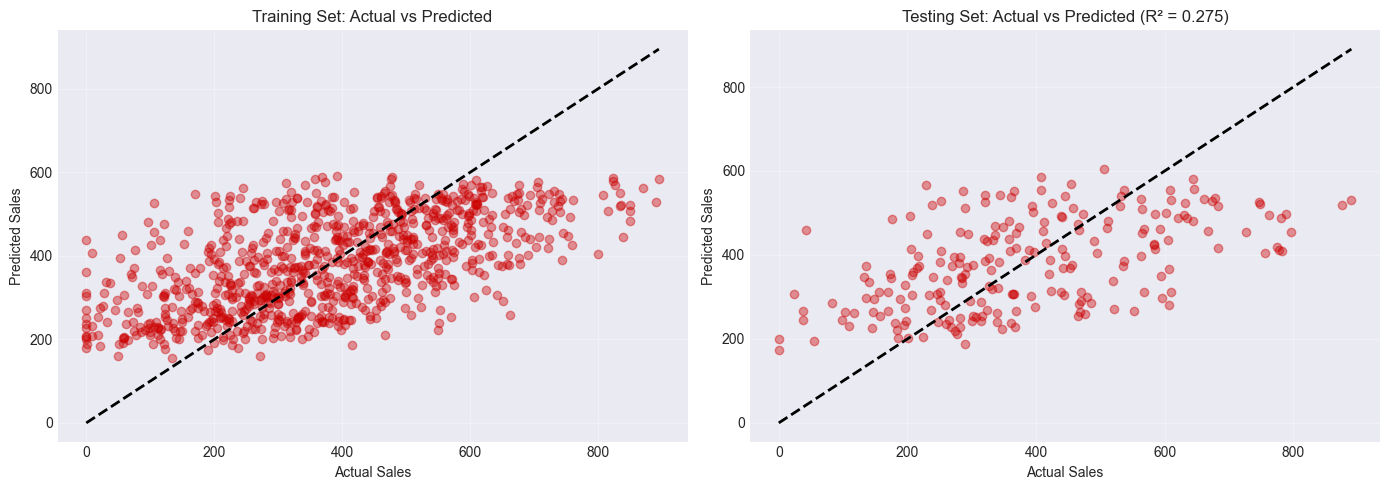

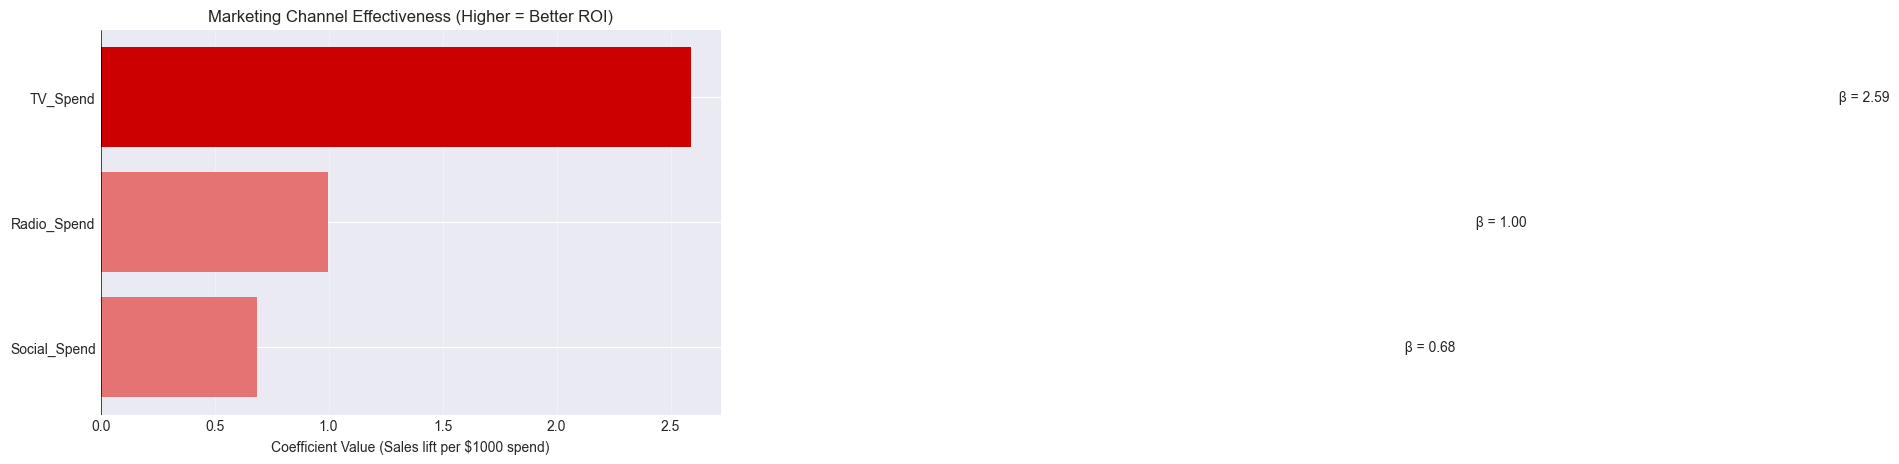


✓ Regression visualizations saved as:
  - coca_cola_regression_results.png
  - coca_cola_feature_importance.png

ARIMA TIME SERIES: DEMAND FORECASTING

Monthly sales data shape: 36 months
Monthly sales range: $7,792 to $16,808

--------------------------------------------------
STATIONARITY TEST (Augmented Dickey-Fuller)
--------------------------------------------------
ADF Statistic: -4.070952
p-value: 0.001081
Critical Values:
   1%: -3.724
   5%: -2.986
   10%: -2.633

✓ Data is stationary (p < 0.05) - ARIMA can be applied directly


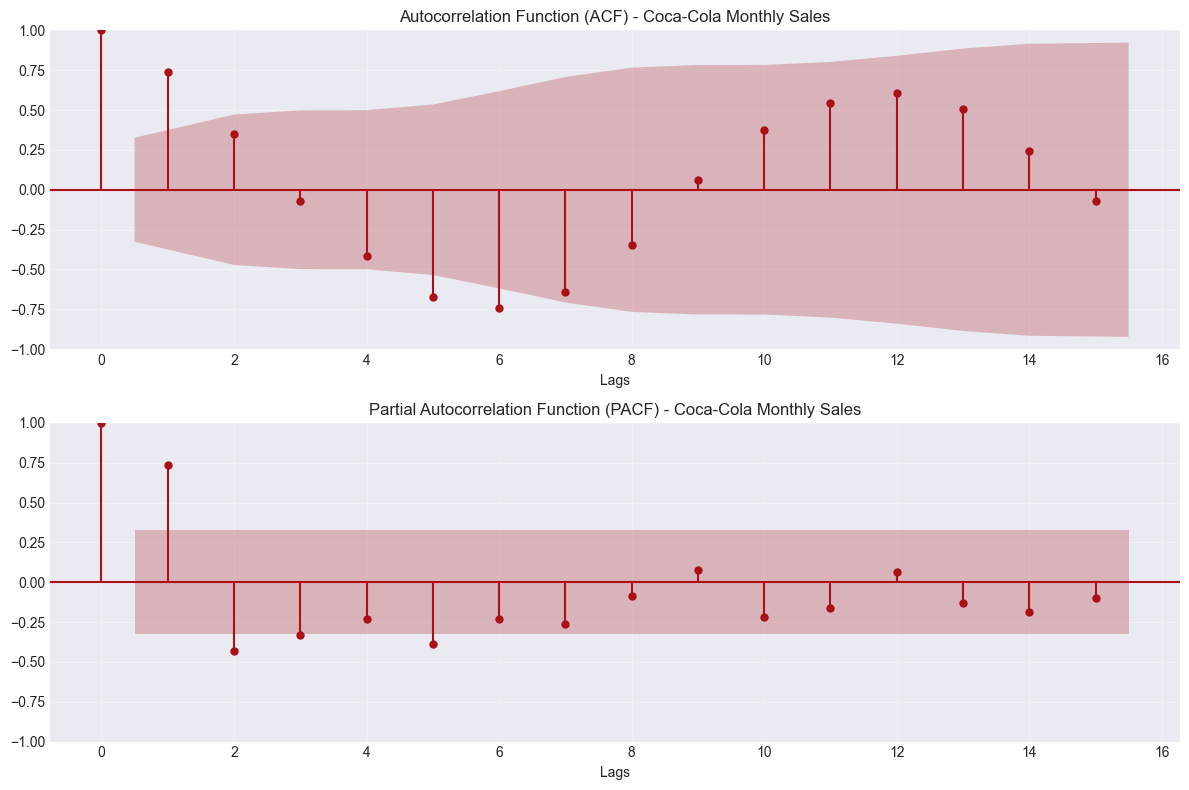


--------------------------------------------------
ARIMA MODEL SELECTION (based on AIC)
--------------------------------------------------
ARIMA(0,0,0) - AIC: 678.42
ARIMA(0,0,1) - AIC: 657.62
ARIMA(0,0,2) - AIC: 642.98
ARIMA(0,0,3) - AIC: 644.97
ARIMA(0,1,0) - AIC: 629.84
ARIMA(0,1,1) - AIC: 628.54
ARIMA(0,1,2) - AIC: 628.93
ARIMA(0,1,3) - AIC: 630.31
ARIMA(1,0,0) - AIC: 648.88
ARIMA(1,0,1) - AIC: 646.41
ARIMA(1,0,2) - AIC: 659.53
ARIMA(1,0,3) - AIC: 643.07
ARIMA(1,1,0) - AIC: 627.24
ARIMA(1,1,1) - AIC: 628.61
ARIMA(1,1,2) - AIC: 630.05
ARIMA(1,1,3) - AIC: 631.50
ARIMA(2,0,0) - AIC: 641.11
ARIMA(2,0,1) - AIC: 622.24
ARIMA(2,0,2) - AIC: 607.98
ARIMA(2,0,3) - AIC: 611.84
ARIMA(2,1,0) - AIC: 628.20
ARIMA(2,1,1) - AIC: 629.28
ARIMA(2,1,2) - AIC: 631.29
ARIMA(2,1,3) - AIC: 630.51
ARIMA(3,0,0) - AIC: 636.05
ARIMA(3,0,1) - AIC: 619.11
ARIMA(3,0,2) - AIC: 611.50
ARIMA(3,0,3) - AIC: 612.90
ARIMA(3,1,0) - AIC: 630.11
ARIMA(3,1,1) - AIC: 630.81
ARIMA(3,1,2) - AIC: 619.68
ARIMA(3,1,3) - AIC: 621

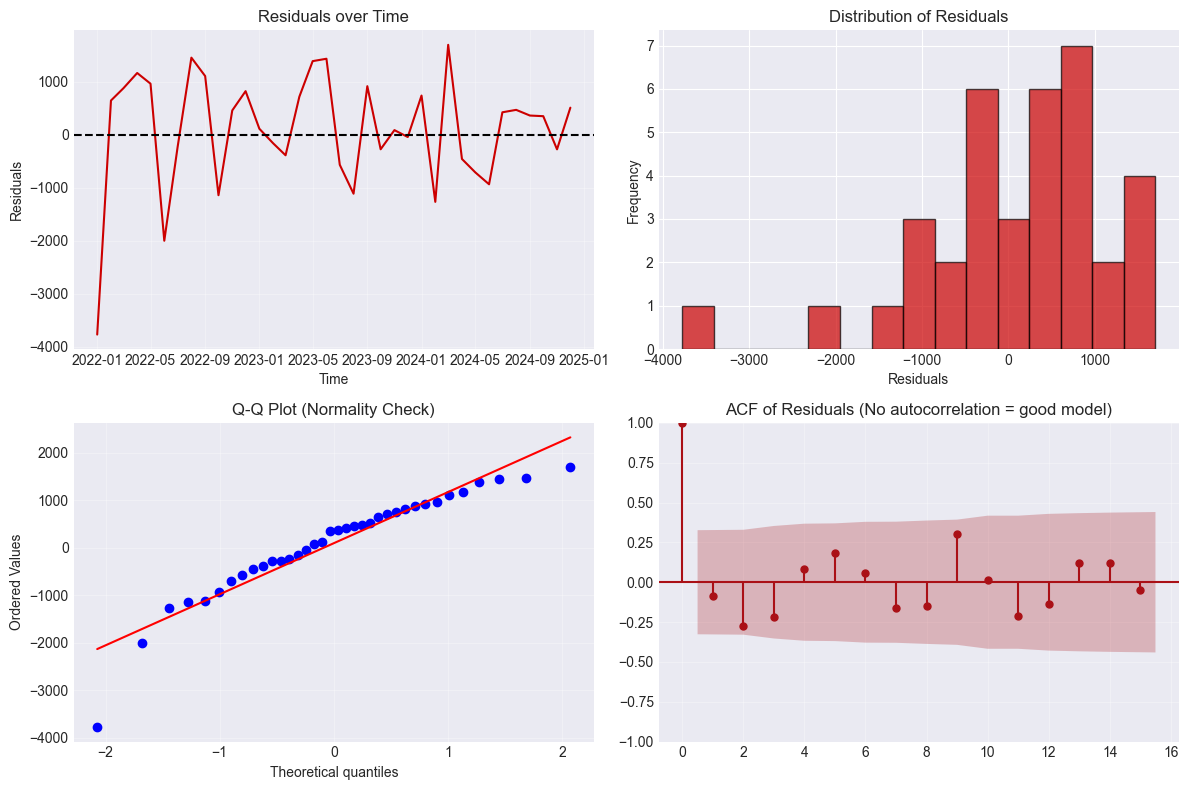


✓ ARIMA diagnostics saved as: coca_cola_arima_diagnostics.png


ValueError: Invalid frequency: M. Failed to parse with error message: ValueError("'M' is no longer supported for offsets. Please use 'ME' instead.")

In [9]:
# =============================================================================
# SCRIPT EXECUTION
# =============================================================================

if __name__ == "__main__":
    main()
